In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv('datasets/mushroom_cleaned.csv')
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [4]:
df.columns

Index(['cap-diameter', 'cap-shape', 'gill-attachment', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'season', 'class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     54035 non-null  int64  
 1   cap-shape        54035 non-null  int64  
 2   gill-attachment  54035 non-null  int64  
 3   gill-color       54035 non-null  int64  
 4   stem-height      54035 non-null  float64
 5   stem-width       54035 non-null  int64  
 6   stem-color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


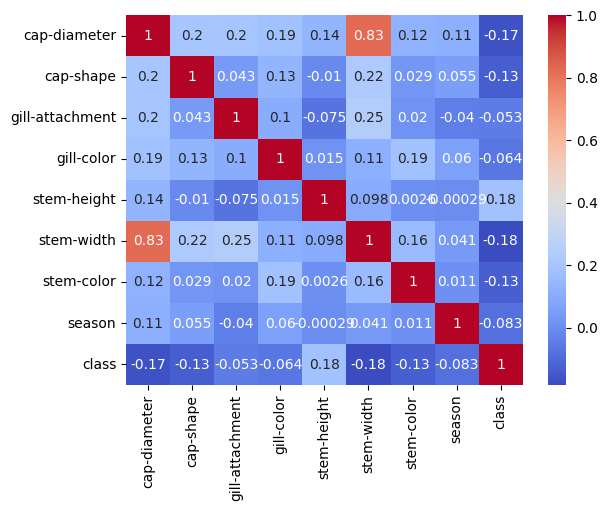

In [6]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.show()

corr_values = df.corr()['class'].drop('class')

In [7]:
x = df.drop('class', axis=1)
y = df['class']

In [8]:
#split dataset to train/test
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2,random_state=42)

In [14]:
# Logistic regression
logistic_reg = LogisticRegression()

logistic_reg.fit(x_train, y_train)

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [15]:
y_pred = logistic_reg.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 1, 0], dtype=int64)

In [16]:
#accuracy

acc = accuracy_score(y_test, y_pred)
print(acc)

0.632367909688165


In [17]:
# F1 score
f1 = f1_score(y_test, y_pred)
print(f1)

0.6681146103082449


In [18]:
# SVM
sv_machine = svm.SVC(kernel='linear')

sv_machine.fit(x_train, y_train)

y_pred = sv_machine.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 1, 0], dtype=int64)

In [19]:
#accuracy

acc = accuracy_score(y_test, y_pred)
print(acc)

0.6222818543536597


In [20]:
f1 = f1_score(y_test, y_pred)
print(f1)

0.6419298245614035


In [9]:
# Decision tree

des_tree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
des_tree.fit(x_train, y_train)

y_pred_dt = des_tree.predict(x_test)
y_pred_dt

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [10]:
acc = accuracy_score(y_test, y_pred_dt)
print(acc)

0.7030628296474507


In [11]:
f1 = f1_score(y_test, y_pred_dt)
print(f1)

0.714780908363701


In [12]:
# Random forest
rand_forest = RandomForestClassifier(n_estimators=100,random_state=42)
rand_forest.fit(x_train,y_train)

y_pred_rf = rand_forest.predict(x_test)
y_pred_rf

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [13]:
acc = accuracy_score(y_test, y_pred_rf)
print(acc)

0.9909318034607199


In [14]:
f1 = f1_score(y_test, y_pred_rf)
print(f1)

0.9916977295831921


In [15]:
# XGBClassifier

xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [16]:
y_pred_xg = xgb.predict(x_test)
y_pred_xg

array([0, 1, 0, ..., 1, 0, 1])

In [17]:
acc = accuracy_score(y_test, y_pred_xg)
print(acc)

0.9713148884981956


In [18]:
f1 = f1_score(y_test, y_pred_xg)
print(f1)

0.9736035422343324


In [ ]:
# Random forest and XGBC shows the best results